
--- After Example 1 (('Sedan', 'Affordable', 'Petrol', 'Automatic', 'High') -> Yes) ---
S (specific boundary):
   ('Sedan', 'Affordable', 'Petrol', 'Automatic', 'High')
G (general boundary):
   ('?', '?', '?', '?', '?')

--- After Example 2 (('Sedan', 'Affordable', 'Diesel', 'Automatic', 'High') -> Yes) ---
S (specific boundary):
   ('Sedan', 'Affordable', '?', 'Automatic', 'High')
G (general boundary):
   ('?', '?', '?', '?', '?')

--- After Example 3 (('SUV', 'Expensive', 'Diesel', 'Manual', 'Low') -> No) ---
S (specific boundary):
   ('Sedan', 'Affordable', '?', 'Automatic', 'High')
G (general boundary):
   ('?', 'Affordable', '?', '?', '?')
   ('?', '?', '?', '?', 'High')
   ('?', '?', '?', 'Automatic', '?')
   ('Sedan', '?', '?', '?', '?')

--- After Example 4 (('Sedan', 'Affordable', 'Diesel', 'Automatic', 'Low') -> Yes) ---
S (specific boundary):
   ('Sedan', 'Affordable', '?', 'Automatic', '?')
G (general boundary):
   ('?', 'Affordable', '?', '?', '?')
   ('?', '?', '?', 'Aut

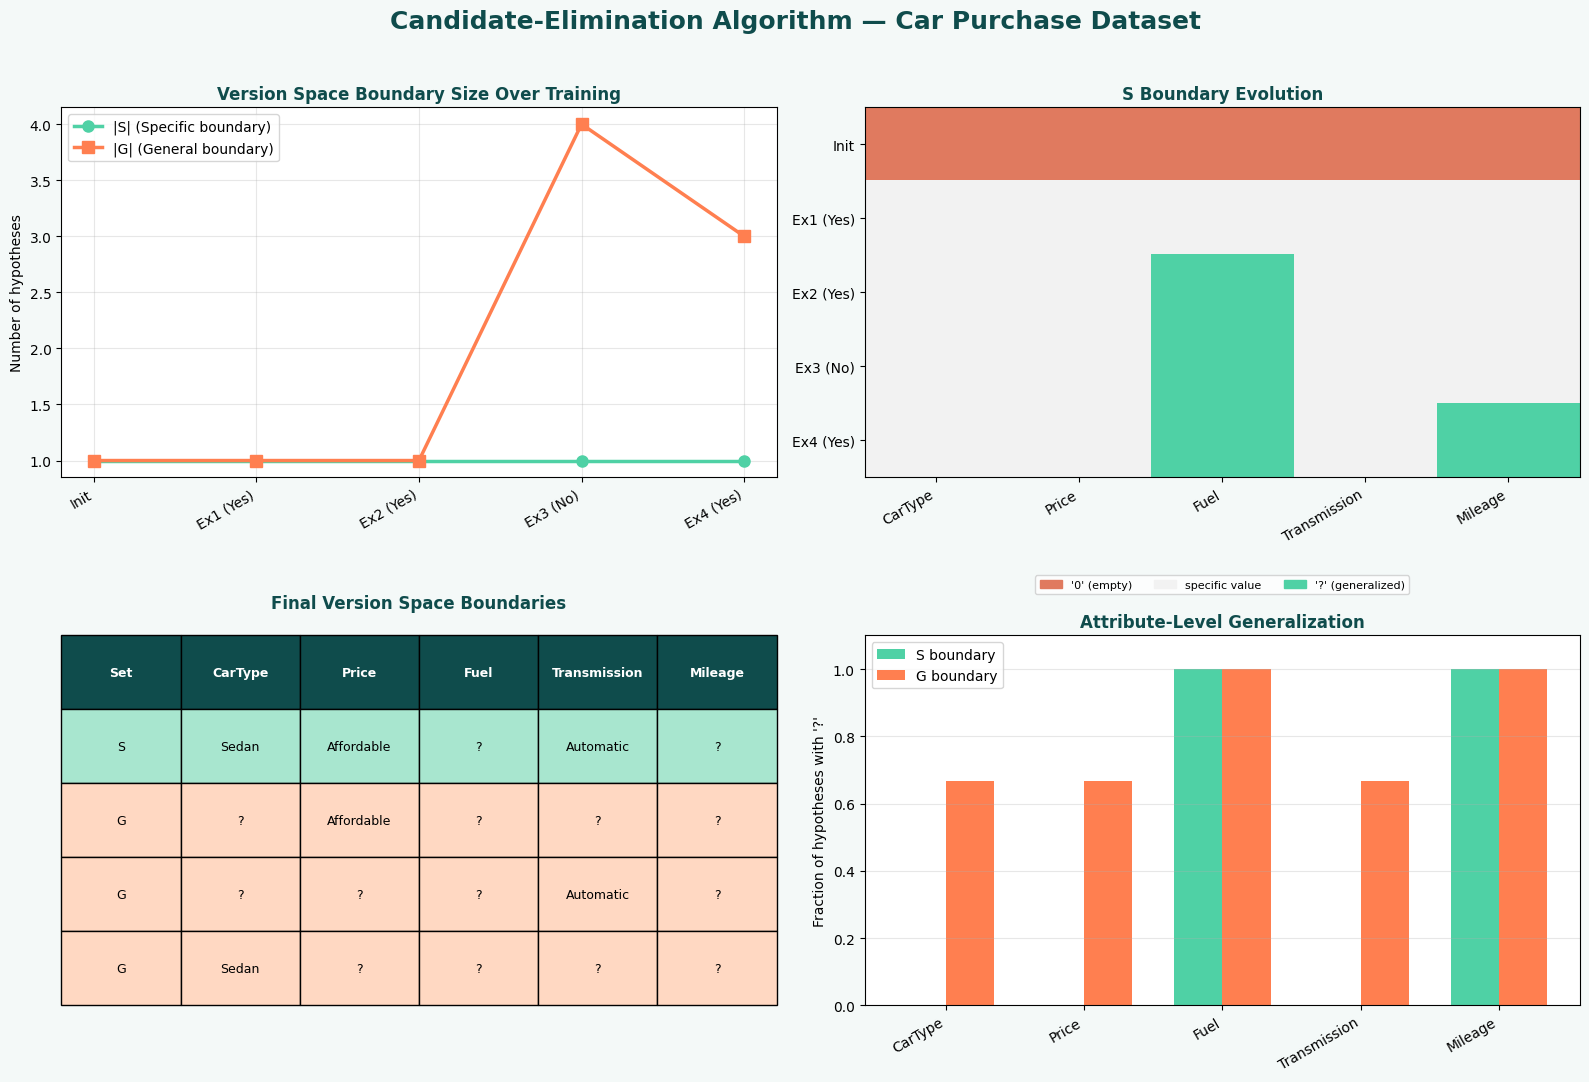


Saved visualization to candidate_elimination_car_analysis.png


In [1]:
# =========================================================
# CANDIDATE ELIMINATION ALGORITHM — NEW DATASET
# Dataset: Car Purchase
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# ---------------------------------------------------------
# 1. DATASET
# ---------------------------------------------------------
# Attributes:
# CarType, Price, Fuel, Transmission, Mileage
#
# Target:
# BuyCar = Yes / No

attributes = [
    'CarType',
    'Price',
    'Fuel',
    'Transmission',
    'Mileage'
]

data = [
    ['Sedan', 'Affordable', 'Petrol', 'Automatic', 'High', 'Yes'],
    ['Sedan', 'Affordable', 'Diesel', 'Automatic', 'High', 'Yes'],
    ['SUV',   'Expensive',  'Diesel', 'Manual',    'Low',  'No'],
    ['Sedan', 'Affordable', 'Diesel', 'Automatic', 'Low',  'Yes'],
]

X = [row[:-1] for row in data]
y = [row[-1] for row in data]

n_attributes = len(attributes)


# ---------------------------------------------------------
# 2. HELPER FUNCTIONS
# ---------------------------------------------------------

def more_general(h1, h2):
    """Return True if h1 is more general than or equal to h2."""
    for x, y_ in zip(h1, h2):

        if x == '?':
            continue

        if x == '0':
            return False

        if x != y_ and y_ != '0':
            return False

    return True


def consistent(h, instance):
    """Check whether hypothesis h matches an instance."""
    for hx, ix in zip(h, instance):

        if hx == '?':
            continue

        if hx != ix:
            return False

    return True


def min_generalizations(h, instance):
    """Return minimal generalizations of h that match instance."""
    new_h = list(h)

    for i in range(len(h)):

        if h[i] == '0':
            new_h[i] = instance[i]

        elif h[i] != instance[i]:
            new_h[i] = '?'

    return [tuple(new_h)]


def min_specializations(h, domains, instance):
    """Return minimal specializations of h that do NOT match instance."""

    results = []

    for i in range(len(h)):

        if h[i] == '?':

            for val in domains[i]:

                if val != instance[i]:

                    new_h = list(h)
                    new_h[i] = val
                    results.append(tuple(new_h))

        elif h[i] != '0':

            new_h = list(h)
            new_h[i] = '0'
            results.append(tuple(new_h))

    return results


def remove_more_general(hyps):
    """
    For S: remove hypotheses that are more general than another
    hypothesis in the same set.
    """
    return [
        h for h in hyps
        if not any(
            h != h2 and more_general(h2, h)
            for h2 in hyps
        )
    ]


def remove_less_general(hyps):
    """
    For G: remove hypotheses that are less general than another
    hypothesis in the same set.
    """
    return [
        h for h in hyps
        if not any(
            h != h2 and more_general(h, h2)
            for h2 in hyps
        )
    ]


# ---------------------------------------------------------
# 3. CANDIDATE ELIMINATION ALGORITHM
# ---------------------------------------------------------

def candidate_elimination(X, y, attributes):

    # Find all possible values for every attribute
    domains = [
        sorted(set(row[i] for row in X))
        for i in range(len(attributes))
    ]

    # S = most specific boundary
    S = [
        tuple(['0'] * n_attributes)
    ]

    # G = most general boundary
    G = [
        tuple(['?'] * n_attributes)
    ]

    # Store the evolution of S and G
    history = {
        'S_sizes': [len(S)],
        'G_sizes': [len(G)],
        'S_sets': [list(S)],
        'G_sets': [list(G)],
        'labels': ['Init']
    }

    # Process each training example
    for idx, (instance, label) in enumerate(zip(X, y)):

        instance = tuple(instance)

        # -------------------------------------------------
        # POSITIVE EXAMPLE
        # -------------------------------------------------
        if label == 'Yes':

            # Remove G hypotheses that do not cover
            # the positive example.
            G = [
                g for g in G
                if consistent(g, instance)
            ]

            new_S = []

            for s in S:

                if consistent(s, instance):

                    # Already covers the example
                    new_S.append(s)

                else:

                    # Generalize S just enough to cover it
                    generalizations = min_generalizations(
                        s, instance
                    )

                    for h in generalizations:

                        # Keep h only if some G is
                        # at least as general as h.
                        if any(
                            more_general(g, h)
                            for g in G
                        ):
                            new_S.append(h)

            S = remove_more_general(
                list(set(new_S))
            )

        # -------------------------------------------------
        # NEGATIVE EXAMPLE
        # -------------------------------------------------
        else:

            # Remove S hypotheses that incorrectly
            # cover the negative example.
            S = [
                s for s in S
                if not consistent(s, instance)
            ]

            new_G = []

            for g in G:

                if not consistent(g, instance):

                    # Already excludes the negative example
                    new_G.append(g)

                else:

                    # Specialize G just enough so that
                    # it no longer covers the negative.
                    specializations = min_specializations(
                        g, domains, instance
                    )

                    for h in specializations:

                        # Keep h only if it is still at least
                        # as general as some S hypothesis.
                        if any(
                            more_general(h, s)
                            for s in S
                        ):
                            new_G.append(h)

            G = remove_less_general(
                list(set(new_G))
            )

        # Save history
        history['S_sizes'].append(len(S))
        history['G_sizes'].append(len(G))
        history['S_sets'].append(list(S))
        history['G_sets'].append(list(G))
        history['labels'].append(
            f'Ex{idx + 1} ({label})'
        )

        # Display current boundaries
        print(
            f"\n--- After Example {idx + 1} "
            f"({instance} -> {label}) ---"
        )

        print("S (specific boundary):")

        for s in S:
            print("  ", s)

        print("G (general boundary):")

        for g in G:
            print("  ", g)

    return S, G, history


# ---------------------------------------------------------
# 4. RUN CANDIDATE ELIMINATION
# ---------------------------------------------------------

S_final, G_final, history = candidate_elimination(
    X, y, attributes
)

print("\n============================")
print("FINAL SPECIFIC BOUNDARY (S):")

for s in S_final:
    print("  ", s)

print("\nFINAL GENERAL BOUNDARY (G):")

for g in G_final:
    print("  ", g)


# ---------------------------------------------------------
# 5. ANALYSIS VISUALIZATIONS
# ---------------------------------------------------------

COL_TEAL = '#0f4c4c'
COL_MINT = '#4fd1a5'
COL_LIGHT = '#a8e6cf'
COL_ACCENT = '#ff7f50'
COL_BG = '#f4f9f8'


def specificity_score(h):
    """
    Encode a hypothesis numerically:
        -1 = '0' (empty)
         0 = specific value
         1 = '?' (generalized)
    """
    return [
        -1 if v == '0'
        else 1 if v == '?'
        else 0
        for v in h
    ]


# ---------------------------------------------------------
# PLOT 1 — S and G boundary size
# ---------------------------------------------------------

fig = plt.figure(
    figsize=(16, 11),
    facecolor=COL_BG
)

fig.suptitle(
    'Candidate-Elimination Algorithm — Car Purchase Dataset',
    fontsize=18,
    fontweight='bold',
    color=COL_TEAL,
    y=0.98
)

ax1 = plt.subplot(2, 2, 1)

steps = range(
    len(history['S_sizes'])
)

ax1.plot(
    steps,
    history['S_sizes'],
    marker='o',
    color=COL_MINT,
    linewidth=2.5,
    label='|S| (Specific boundary)',
    markersize=8
)

ax1.plot(
    steps,
    history['G_sizes'],
    marker='s',
    color=COL_ACCENT,
    linewidth=2.5,
    label='|G| (General boundary)',
    markersize=8
)

ax1.set_xticks(steps)

ax1.set_xticklabels(
    history['labels'],
    rotation=30,
    ha='right'
)

ax1.set_ylabel('Number of hypotheses')

ax1.set_title(
    'Version Space Boundary Size Over Training',
    color=COL_TEAL,
    fontweight='bold'
)

ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_facecolor('white')


# ---------------------------------------------------------
# PLOT 2 — S boundary evolution
# ---------------------------------------------------------

ax2 = plt.subplot(2, 2, 2)

s_track = []

for s_set in history['S_sets']:

    if s_set:
        h = s_set[0]
    else:
        h = tuple(['0'] * n_attributes)

    s_track.append(
        specificity_score(h)
    )

s_matrix = np.array(s_track)

cmap = ListedColormap([
    '#e07a5f',
    '#f2f2f2',
    COL_MINT
])

ax2.imshow(
    s_matrix,
    aspect='auto',
    cmap=cmap,
    vmin=-1,
    vmax=1
)

ax2.set_xticks(
    range(n_attributes)
)

ax2.set_xticklabels(
    attributes,
    rotation=30,
    ha='right'
)

ax2.set_yticks(
    range(len(history['labels']))
)

ax2.set_yticklabels(
    history['labels']
)

ax2.set_title(
    'S Boundary Evolution',
    color=COL_TEAL,
    fontweight='bold'
)

patches = [
    mpatches.Patch(
        color='#e07a5f',
        label="'0' (empty)"
    ),
    mpatches.Patch(
        color='#f2f2f2',
        label='specific value'
    ),
    mpatches.Patch(
        color=COL_MINT,
        label="'?' (generalized)"
    )
]

ax2.legend(
    handles=patches,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=3,
    fontsize=8
)


# ---------------------------------------------------------
# PLOT 3 — FINAL S vs G
# ---------------------------------------------------------

ax3 = plt.subplot(2, 2, 3)

ax3.axis('off')

ax3.set_title(
    'Final Version Space Boundaries',
    color=COL_TEAL,
    fontweight='bold',
    pad=20
)

table_data = []
row_colors = []

for s in S_final:

    table_data.append(
        ['S'] + list(s)
    )

    row_colors.append(COL_LIGHT)


for g in G_final:

    table_data.append(
        ['G'] + list(g)
    )

    row_colors.append('#ffd8c2')


col_labels = [
    'Set'
] + attributes

tbl = ax3.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
    bbox=[0, 0, 1, 1]
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)

for i, color in enumerate(row_colors):

    for j in range(len(col_labels)):

        tbl[
            (i + 1, j)
        ].set_facecolor(color)


for j in range(len(col_labels)):

    tbl[
        (0, j)
    ].set_facecolor(COL_TEAL)

    tbl[
        (0, j)
    ].set_text_props(
        color='white',
        fontweight='bold'
    )


# ---------------------------------------------------------
# PLOT 4 — ATTRIBUTE-LEVEL GENERALITY
# ---------------------------------------------------------

ax4 = plt.subplot(2, 2, 4)

s_generality = np.mean(
    [
        [
            1 if v == '?' else 0
            for v in s
        ]
        for s in S_final
    ],
    axis=0
) if S_final else np.zeros(n_attributes)


g_generality = np.mean(
    [
        [
            1 if v == '?' else 0
            for v in g
        ]
        for g in G_final
    ],
    axis=0
) if G_final else np.zeros(n_attributes)


x_pos = np.arange(
    n_attributes
)

width = 0.35

ax4.bar(
    x_pos - width / 2,
    s_generality,
    width,
    label='S boundary',
    color=COL_MINT
)

ax4.bar(
    x_pos + width / 2,
    g_generality,
    width,
    label='G boundary',
    color=COL_ACCENT
)

ax4.set_xticks(x_pos)

ax4.set_xticklabels(
    attributes,
    rotation=30,
    ha='right'
)

ax4.set_ylabel(
    "Fraction of hypotheses with '?'"
)

ax4.set_title(
    'Attribute-Level Generalization',
    color=COL_TEAL,
    fontweight='bold'
)

ax4.legend()

ax4.grid(
    alpha=0.3,
    axis='y'
)

ax4.set_ylim(
    0,
    1.1
)

ax4.set_facecolor('white')


plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.savefig(
    'candidate_elimination_car_analysis.png',
    dpi=150,
    facecolor=COL_BG
)

plt.show()

print(
    "\nSaved visualization to "
    "candidate_elimination_car_analysis.png"
)
